In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.interpolate import PchipInterpolator
from scipy.io import loadmat

from dataclasses import dataclass, replace

# set plot showing style
%config InlineBackend.figure_format = 'retina'

# load self-defined modules
%load_ext autoreload
%autoreload 2
from src.model import ModelParameters, ConsolidationParameters, HebbianSequenceModel
from src.experiment import build_exp_graph, make_trials, random_walk
from src.plotNet import make_kk_layout, plot_original_network, plot_learned_network
from src.plotBehav import plot_day1_byType, plot_day2_byType, plot_delta_byType

import statsmodels.api as sm
import statsmodels.formula.api as smf
from tqdm.auto import tqdm

d:\anaconda3\envs\neuro\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
palette_whole = sns.color_palette('Paired', 12)
my_color = [palette_whole[i] for i in [0, 2, 6, 4]]
my_color_s2 = [palette_whole[i] for i in [1, 3, 7, 5]]

In [3]:
def load_design(subj):
    inFolder = 'C:\\Users\\Zhou Xiaoyue\\OneDrive - University College London\\Guenevere\\UCL\\Ph.D.project\\code.exp\\design\\'
    filename = inFolder + 'des_{}_subj.mat'.format(subj)
    des = loadmat(filename)
    
    expo_seq = des['dm_expo']['stim_seq'][0,0]
    trials_s1 = des['dm_2AFC']['seq_mat'][0,0]
    trials_s2 = des['dm_2AFC_conso']['seq_mat'][0,0]
    
    return expo_seq-1, trials_s1-1, trials_s2-1  # adjust index difference

def load_result(subj):
    inFolder = 'C:\\Users\\Zhou Xiaoyue\\OneDrive - University College London\\Guenevere\\UCL\\Ph.D.project\\code.exp\\data_batch2\\'

    # session 1
    filename = inFolder + 'ForcedChoice_{}_subj.mat'.format(subj)
    dat = loadmat(filename)

    rt = dat['result_2AFC']['rt'][0,0]
    answ = dat['result_2AFC']['answ'][0,0]
    resp = dat['result_2AFC']['resp'][0,0]

    result_s1 = pd.DataFrame({
        'rt': rt.ravel().astype(float),
        'answ': -1 * answ.ravel().astype(int) + 2,
        'resp': -1 * resp.ravel().astype(int) + 2
    })

    # session 2
    filename = inFolder + 'ForcedChoice_{}_subj_conso.mat'.format(subj)
    dat = loadmat(filename)

    rt = dat['result_2AFC']['rt'][0,0]
    answ = dat['result_2AFC']['answ'][0,0]
    resp = dat['result_2AFC']['resp'][0,0]

    result_s2 = pd.DataFrame({
        'rt': rt.ravel().astype(float),
        'answ': -1 * answ.ravel().astype(int) + 2,
        'resp': -1 * resp.ravel().astype(int) + 2
    })

    result_s1['session'] = 'S1'
    result_s1['trial'] = np.arange(0, 400).astype(int)
    result_s2['session'] = 'S2'
    result_s2['trial'] = np.arange(0, 400).astype(int)

    return pd.concat([result_s1, result_s2])

def seqMat_to_trials(seq_mat, adjacency, community):
    n_trial = seq_mat.shape[0]
    trial = np.arange(0,400)
    block = trial // 80
    cue = seq_mat[:,-2].astype(int)
    target = seq_mat[:,-1].astype(int)

    legal = adjacency[cue, target].astype(bool)
    within = community[cue] == community[target]
    sequence = seq_mat.astype(int)
    sequence = [row.tolist() for row in sequence]

    membership_lab = np.where(within, 'within', 'between')
    legal_lab = np.where(legal, 'legal', 'illegal')
    trial_type = np.char.add(membership_lab, '_')
    trial_type = np.char.add(trial_type, legal_lab)

    df = pd.DataFrame({
        'trial': trial,
        'trial_in_block': np.tile(np.arange(80), 5),
        'block': block,
        'cue': cue,
        'target': target,
        'legal': legal,
        'within': within,
        'sequence': sequence,
        'trial_type': trial_type
    })
    return df

In [4]:
def simulate_analytic_one_beta(beta, subj_list, adjacency, community, session):
    adjacency = np.asarray(adjacency, dtype=float)
    A = adjacency / adjacency.sum(axis=1, keepdims=True)
    gamma = np.exp(-beta)
    I = np.eye(A.shape[0])

    # annalytical solution
    A_app = (1 - gamma) * A @ np.linalg.inv(I - gamma * A)

    subject_table = []
    for subj in subj_list:
        _, trials_s1, trials_s2 = load_design(subj)
        if session == 'S1':
            trials = seqMat_to_trials(
                trials_s1,
                adjacency=adjacency,
                community=community
            )
        elif session == 'S2':
            trials = seqMat_to_trials(
                trials_s2,
                adjacency=adjacency,
                community=community
            )
        else:
            raise(ValueError('Wrong session string - should be either S1 or S2.'))

        result = load_result(subj)
        result = result[result['session'] == session]

        grand = pd.concat([trials, result], axis=1)
        # remove time-out trials
        grand = grand.loc[grand['resp'].isin([0,1])].copy()
        grand['subj'] = str(subj)
        subject_table.append(grand)


    output = pd.concat(subject_table, ignore_index=True)
    output['familiarity'] = A_app[output['cue'].to_numpy(), output['target'].to_numpy()]
    return output

In [5]:
def simulate_one_beta(beta, subj_list, adjacency, community):
    subject_table = []
    for subj in subj_list:
        # load relevent data
        expo_seq, trials_s1, trials_s2 = load_design(subj)
        result = load_result(subj)
        result_s1 = (
            result
            .loc[result["session"] == "S1"]
            .copy()
            .reset_index(drop=True)
        )
        result_s2 = (
            result
            .loc[result["session"] == "S2"]
            .copy()
            .reset_index(drop=True)
        )
        trials_s1 = seqMat_to_trials(
            trials_s1,
            adjacency=adjacency,
            community=community
        )
        trials_s2 = seqMat_to_trials(
            trials_s2,
            adjacency=adjacency,
            community=community
        )

        # create a new model for each subject
        params = ModelParameters(
            beta = float(beta),
            lr = 1.0,
            # frozen test
            lr_test_prefix=0.0,
            lr_test_probe=0.0,
            reset_current_activity=True,
            criterion_offset=0.0
        )
        model = HebbianSequenceModel(
            n_nodes=adjacency.shape[0],
            params=params
        )

        # learn exposure
        model.learn_exposure(expo_seq[0,:])
        model.learn_exposure(expo_seq[1,:])

        sim_s1 = model.run_test_phase(trials_s1)
        sim_s2 = model.run_test_phase(trials_s2)

        if len(sim_s1) != len(result_s1):
            raise ValueError(
                f"Subject {subj}: "
                f"{len(sim_s1)} model trials but "
                f"{len(result_s1)} behavioral trials."
            )
        
        if len(sim_s2) != len(result_s2):
            raise ValueError(
                f"Subject {subj}: "
                f"{len(sim_s2)} model trials but "
                f"{len(result_s2)} behavioral trials."
            )
        
        # merge dataset
        grand1 = pd.concat([result_s1, sim_s1], axis=1)
        grand2 = pd.concat([result_s2, sim_s2], axis=1)

        # remove timeout trials
        grand1 = grand1.loc[
            grand1["resp"].isin([0, 1])
        ].copy()
        grand2 = grand2.loc[
            grand2["resp"].isin([0, 1])
        ].copy()

        # add subject idx
        grand1['subj'] = subj
        grand2['subj'] = subj

        subject_table.append(grand2)
    
    return pd.concat(subject_table, ignore_index=True)



In [6]:
def fit_one_beta(df):
    fam_mean = df["familiarity"].mean()
    fam_sd = df["familiarity"].std(ddof=0)

    df["model_fam_z"] = (df["familiarity"] - fam_mean) / fam_sd

    fit = smf.glm(
        formula="resp ~ model_fam_z + C(subj)",
        data=df,
        family=sm.families.Binomial()
    ).fit(
        maxiter=200,
        disp=False
    )

    return {
        "logLik": float(fit.llf),
        "AIC": float(fit.aic),
        "BIC_llf": float(fit.bic_llf),
        "slope": float(
            fit.params["model_fam_z"]
        ),
        "slope_se": float(
            fit.bse["model_fam_z"]
        ),
        "slope_p": float(
            fit.pvalues["model_fam_z"]
        ),
        "n_trial": int(fit.nobs),
        "converged": bool(fit.converged),
        "fam_mean": float(fam_mean),
        "fam_sd": float(fam_sd)
    }

In [ ]:
def bootstrap_analysis(betas, subj_list, adjacency, community, session):
    # produce a table of beta vs log liklihood, each data point stand for each permutation
    for beta in betas:
        df_full = simulate_analytic_one_beta(beta, subj_list, adjacency, community, session)

        # get participants
    return 

betas = np.logspace(-2, 1, 100)
n_iter = 10
session = 'S1'
bootstrap_analysis(betas, subj_list, adjacency, community, session)

,trial,trial_in_block,block,cue,target,legal,within,sequence,trial_type,rt,answ,resp,session,trial,subj,familiarity
0,0,0,0,4,1,True,True,"[4, 1, 0, 1, 3, 0, 3, 2, 4, 1]",within_legal,1.184496,1,1,S1,0,121,0.127868
1,2,2,0,7,9,False,True,"[7, 6, 5, 9, 5, 9, 10, 8, 7, 9]",within_illegal,0.812657,0,1,S1,2,121,0.127347
2,3,3,0,6,0,False,False,"[6, 5, 6, 5, 4, 5, 6, 5, 6, 0]",between_illegal,1.034400,0,0,S1,3,121,0.044407
3,4,4,0,10,3,False,False,"[6, 7, 6, 5, 8, 10, 8, 7, 10, 3]",between_illegal,1.054767,0,1,S1,4,121,0.056522
4,5,5,0,2,1,False,True,"[7, 6, 9, 5, 4, 2, 3, 4, 2, 1]",within_illegal,1.790080,0,1,S1,5,121,0.108576
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11548,395,75,4,6,3,False,False,"[7, 6, 5, 8, 10, 7, 6, 7, 6, 3]",between_illegal,0.827748,0,1,S1,395,154,0.035571
11549,396,76,4,0,8,False,False,"[4, 1, 3, 4, 1, 0, 3, 1, 0, 8]",between_illegal,1.386725,0,1,S1,396,154,0.054627
11550,397,77,4,10,8,True,True,"[1, 0, 3, 1, 4, 5, 6, 7, 10, 8]",within_legal,0.435835,1,0,S1,397,154,0.149155
11551,398,78,4,4,7,False,False,"[10, 9, 5, 9, 10, 0, 2, 3, 4, 7]",between_illegal,0.571591,0,1,S1,398,154,0.033305


### Simulation

In [7]:
adjacency, community, node_degree = build_exp_graph()
betas = np.logspace(-2, 1, 100)

# read in subject data
subj_full = list(range(121, 155))
idx_remov = [128, 134, 140, 144, 152]
subj_list = [x for x in subj_full if x not in idx_remov]


# beta loop
fit_records1 = []
fit_records2 = []
for beta in tqdm(betas, desc='Sweeping beta'):
    # Session 1
    full_tbl  = simulate_analytic_one_beta(beta, 
                                           subj_list, 
                                           adjacency, 
                                           community,
                                           session='S1')
    fit_result = fit_one_beta(full_tbl)
    fit_records1.append({
            "beta": float(beta),
            **fit_result
    })
    
    # Session 2
    full_tbl  = simulate_analytic_one_beta(beta, 
                                           subj_list, 
                                           adjacency, 
                                           community,
                                           session='S2')
    fit_result = fit_one_beta(full_tbl)
    fit_records2.append({
            "beta": float(beta),
            **fit_result
    })
    

Sweeping beta: 100%|██████████| 10/10 [00:08<00:00,  1.12it/s]


In [ ]:
# adjacency, community, node_degree = build_exp_graph()
# betas = np.logspace(-2, 1, 100)

# # read in subject data
# subj_full = list(range(121, 155))
# idx_remov = [128, 134, 140, 144, 152]
# subj_list = [x for x in subj_full if x not in idx_remov]


# # beta loop
# fit_records = []
# for beta in tqdm(betas, desc='Sweeping beta'):
#     full_tbl  = simulate_one_beta(beta, 
#                                   subj_list, 
#                                   adjacency, 
#                                   community)
#     fit_result = fit_one_beta(full_tbl)
#     fit_records.append({
#             "beta": float(beta),
#             **fit_result
#     })
    

Sweeping beta: 100%|██████████| 100/100 [03:52<00:00,  2.33s/it]


In [50]:
fit_results1 = pd.DataFrame(fit_records1)
fit_results1 = fit_results1.sort_values("beta").reset_index(drop=True)

fit_results2 = pd.DataFrame(fit_records2)
fit_results2 = fit_results2.sort_values("beta").reset_index(drop=True)

In [56]:
valid_results1 = fit_results1.dropna(
    subset=["logLik"]
).copy()
valid_results2 = fit_results2.dropna(
    subset=["logLik"]
).copy()

# print(f"Best beta: {best_beta:.6g}")
# print(f"Log-likelihood: {best_row['logLik']:.3f}")
# print(f"AIC: {best_row['AIC']:.3f}")
# print(f"Model slope: {best_row['slope']:.3f}")

fit_results1["delta_logLik"] = (
    fit_results1["logLik"]
    - fit_results1["logLik"].max()
)
fit_results2["delta_logLik"] = (
    fit_results2["logLik"]
    - fit_results2["logLik"].max()
)

# beta_interval = fit_results.loc[
#     fit_results["delta_logLik"] >= -1.92,
#     "beta"
# ]

# if not beta_interval.empty:
#     print(
#         "Approximate likelihood interval: "
#         f"[{beta_interval.min():.6g}, "
#         f"{beta_interval.max():.6g}]"
#     )

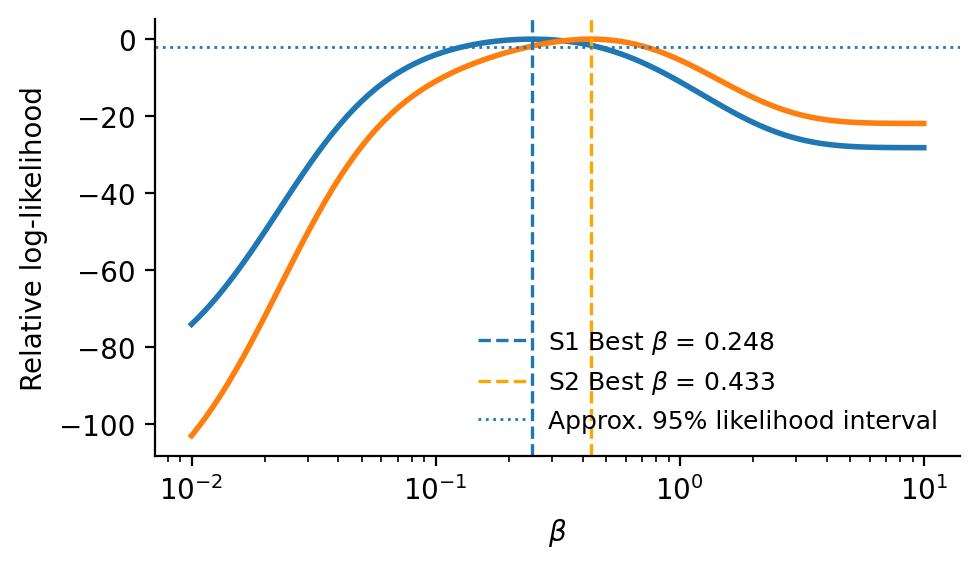

In [62]:
fig, ax = plt.subplots(
    figsize=(5, 3)
)

ax.plot(
    fit_results1["beta"],
    fit_results1["delta_logLik"],
    linewidth=2
)
ax.plot(
    fit_results2["beta"],
    fit_results2["delta_logLik"],
    linewidth=2
)

best_idx = valid_results1["logLik"].idxmax()
best_row = valid_results1.loc[best_idx]
best_beta = best_row["beta"]
ax.axvline(
    best_beta,
    linestyle="--",
    linewidth=1.2,
    label=fr"S1 Best $\beta$ = {best_beta:.3g}"
)

best_idx = valid_results2["logLik"].idxmax()
best_row = valid_results2.loc[best_idx]
best_beta = best_row["beta"]
ax.axvline(
    best_beta,
    linestyle="--",
    linewidth=1.2,
    label=fr"S2 Best $\beta$ = {best_beta:.3g}",
    c='orange'
)

ax.axhline(
    -1.92,
    linestyle=":",
    linewidth=1,
    label="Approx. 95% likelihood interval"
)

ax.set_xscale("log")

ax.set_xlabel(r"$\beta$")
ax.set_ylabel("Relative log-likelihood")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    fontsize=9,
)

fig.tight_layout()
plt.show()

In [ ]:
# 画出最佳 beta的prediction

In [ ]:
# trial_order = ['within_legal',
#             'between_legal',
#             'within_illegal',
#             'between_illegal']
# measure = 'p_yes'
# dat4plot = (
#     sim_s1.groupby(['trial_type'], as_index=False)
#     .agg(mean_dat = (measure, 'mean'),
#          sd_dat = (measure, 'std'),
#          n_trial = (measure, 'count'))
# )

# dat4plot['trial_type'] = pd.Categorical(
#     dat4plot['trial_type'],
#     categories=trial_order,
#     ordered=True
# )

# dat4plot = dat4plot.sort_values('trial_type').reset_index(drop=True)

# # plot figures
# fig, ax = plt.subplots(figsize=(3, 2.5))
# x=np.arange(len(dat4plot))
# ax.bar(
#     x, 
#     dat4plot['mean_dat'],
#     # yerr=dat4plot['se_dat'],
#     width=0.4,
#     color=my_color,
#     capsize=5,
#     error_kw={
#         "elinewidth": 1.5,
#         "capthick": 1.5
#     },
# )
# ax.set_xticks(x)
# ax.set_xticklabels(
#     [
#         "Within-legal",
#         "Between-legal",
#         "Within-illegal",
#         "Between-illegal",
#     ],
#     rotation=20,
#     ha='right'
# )

# ax.set_xlabel("Trial type")
# ax.set_ylabel(measure)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.tight_layout()